# DDPM Training Loss Analysis

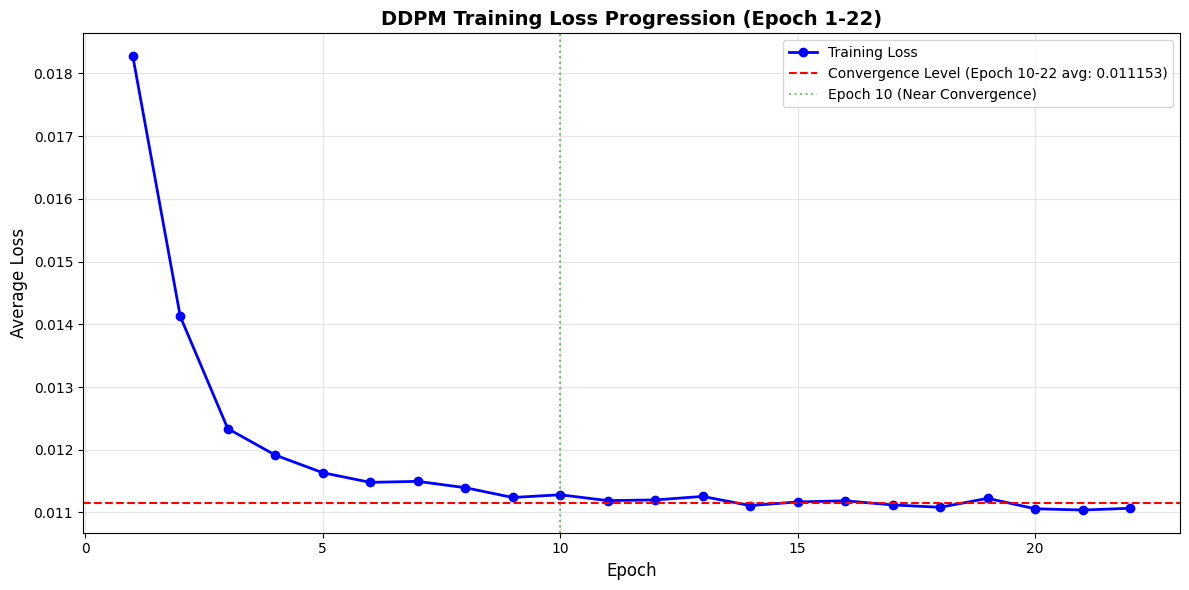

Loss Statistics
Initial Loss (Epoch 1):        0.018278
Final Loss (Epoch 22):         0.011067
Total Reduction:               0.007211 (39.5%)

Epoch 1-9 Reduction:           0.007039
Epoch 10-22 Variation:         ± 0.000076
Epoch 10-22 Mean:              0.011153


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Epoch 1-22 の Loss データ
epochs = list(range(1, 23))
losses = [
    0.018278,  # Epoch 1
    0.014125,  # Epoch 2
    0.012337,  # Epoch 3
    0.011915,  # Epoch 4
    0.011634,  # Epoch 5
    0.011480,  # Epoch 6
    0.011496,  # Epoch 7
    0.011395,  # Epoch 8
    0.011239,  # Epoch 9
    0.011282,  # Epoch 10
    0.011189,  # Epoch 11
    0.011200,  # Epoch 12
    0.011256,  # Epoch 13
    0.011110,  # Epoch 14
    0.011168,  # Epoch 15
    0.011186,  # Epoch 16
    0.011120,  # Epoch 17
    0.011083,  # Epoch 18
    0.011225,  # Epoch 19
    0.011059,  # Epoch 20
    0.011039,  # Epoch 21
    0.011067,  # Epoch 22
]

# グラフ作成
plt.figure(figsize=(12, 6))
plt.plot(epochs, losses, 'b-o', linewidth=2, markersize=6, label='Training Loss')

# 収束ライン（Epoch 10以降の平均）
convergence_line = np.mean(losses[9:])
plt.axhline(y=convergence_line, color='r', linestyle='--', 
            label=f'Convergence Level (Epoch 10-22 avg: {convergence_line:.6f})')

# Epoch 10 に垂直線
plt.axvline(x=10, color='g', linestyle=':', alpha=0.5, label='Epoch 10 (Near Convergence)')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('DDPM Training Loss Progression (Epoch 1-22)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 統計情報
print("="*60)
print("Loss Statistics")
print("="*60)
print(f"Initial Loss (Epoch 1):        {losses[0]:.6f}")
print(f"Final Loss (Epoch 22):         {losses[-1]:.6f}")
print(f"Total Reduction:               {losses[0] - losses[-1]:.6f} ({(1 - losses[-1]/losses[0])*100:.1f}%)")
print(f"\nEpoch 1-9 Reduction:           {losses[0] - losses[8]:.6f}")
print(f"Epoch 10-22 Variation:         ± {np.std(losses[9:]):.6f}")
print(f"Epoch 10-22 Mean:              {convergence_line:.6f}")
print("="*60)

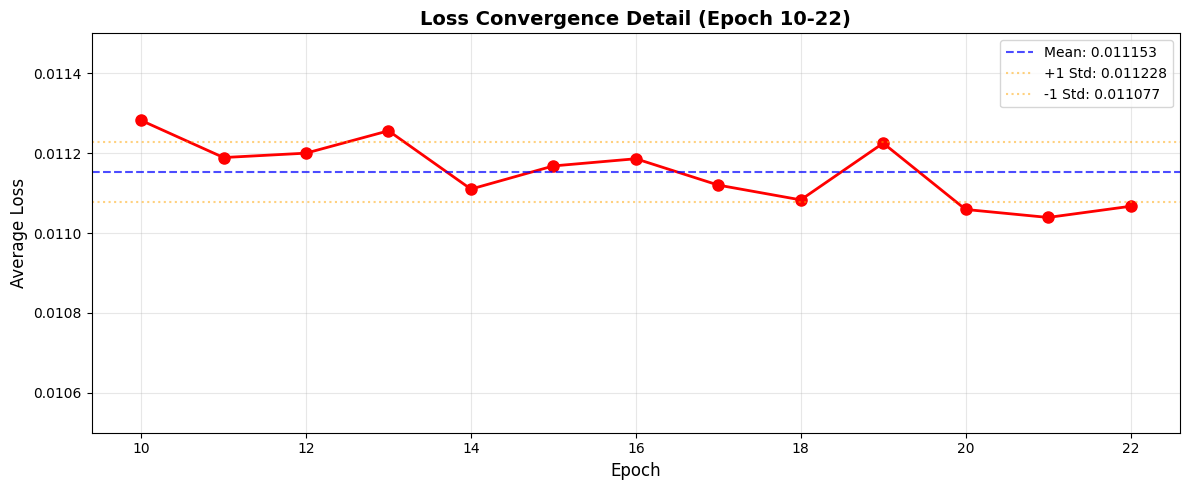


Conclusion:
------------------------------------------------------------
✓ Loss converged around Epoch 10
✓ Epoch 10-22 shows minimal improvement (< 0.0002 variation)
✓ Recommendation: Stop training, use Epoch 20 checkpoint
------------------------------------------------------------


In [2]:
# Epoch 10以降の詳細表示
plt.figure(figsize=(12, 5))
epochs_detail = list(range(10, 23))
losses_detail = losses[9:]

plt.plot(epochs_detail, losses_detail, 'ro-', linewidth=2, markersize=8)
plt.axhline(y=convergence_line, color='b', linestyle='--', alpha=0.7,
            label=f'Mean: {convergence_line:.6f}')

# 上限・下限ライン
plt.axhline(y=convergence_line + np.std(losses_detail), color='orange', 
            linestyle=':', alpha=0.5, label=f'+1 Std: {convergence_line + np.std(losses_detail):.6f}')
plt.axhline(y=convergence_line - np.std(losses_detail), color='orange', 
            linestyle=':', alpha=0.5, label=f'-1 Std: {convergence_line - np.std(losses_detail):.6f}')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Loss Convergence Detail (Epoch 10-22)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ylim([0.0105, 0.0115])
plt.tight_layout()
plt.show()

print("\nConclusion:")
print("-" * 60)
print("✓ Loss converged around Epoch 10")
print("✓ Epoch 10-22 shows minimal improvement (< 0.0002 variation)")
print("✓ Recommendation: Stop training, use Epoch 20 checkpoint")
print("-" * 60)